# **Brain Tumor Classification**

<a id="1"></a>
# 1. Dataset : 
1. 1 [Brain Tumor MRI Dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)

In [1]:
# !pip list

<a id="2"></a>
#  2. Install required packages

In [2]:
# for new conda env excep keggle Machine config
# !pip install --upgrade pip
# !pip install ipywidgets
# !pip install pydot

# # only keggle 
# !sudo apt-get update
# !sudo apt-get install libgl1-mesa-glx
# !apt-get update
# !apt-get install -y libgl1-mesa-glx

!pip install wandb
# !pip install tensorflow[and-cuda]

# !pip uninstall -y tensorboard tb-nightly && pip install tb-nightly  

# !pip install tensorflow tensorflow-addons


!pip install pandarallel

!pip install tabulate
!pip install tf-keras-vis
!pip install lime


# !pip install --unstable-feature=resolver

# !pip check

  Preparing metadata (setup.py) ... done
  Created wheel for pandarallel: filename=pandarallel-1.6.5-py3-none-any.whl size=16672 sha256=1f20f022902ae4e457b4e1d8d83c32f1bbd533d54b61524f1d9c9c867466ab2c
  Stored in directory: /root/.cache/pip/wheels/50/4f/1e/34e057bb868842209f1623f195b74fd7eda229308a7352d47f
Successfully built pandarallel
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 2.7 MB/s eta 0:00:00


In [3]:
# for CPU information
!lscpu

Architecture:                            x86_64
CPU op-mode(s):                          32-bit, 64-bit
Byte Order:                              Little Endian
Address sizes:                           46 bits physical, 48 bits virtual
CPU(s):                                  4
On-line CPU(s) list:                     0-3
Thread(s) per core:                      2
Core(s) per socket:                      2
Socket(s):                               1
NUMA node(s):                            1
Vendor ID:                               GenuineIntel
CPU family:                              6
Model:                                   85
Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz
Stepping:                                3
CPU MHz:                                 2000.188
BogoMIPS:                                4000.37
Hypervisor vendor:                       KVM
Virtualization type:                     full
L1d cache:                               64 KiB
L1i cache:  

In [4]:
# for GPU information
!nvidia-smi

Sat Dec 27 02:13:08 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             27W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

<a id="3"></a>
# 3. Import required packages

In [5]:
import os
import shutil
import datetime
import pytz
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, mixed_precision
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, Input, MaxPooling2D, BatchNormalization,Activation,GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical, plot_model
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score, average_precision_score, balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_recall_fscore_support, precision_score, recall_score, roc_auc_score, log_loss, cohen_kappa_score, matthews_corrcoef
from tabulate import tabulate

import glob

import ipywidgets as widgets
import io

from PIL import Image

import tqdm
from tqdm.notebook import tqdm; 
tqdm.pandas(); # get nice bar


from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')


# Set XLA flags
os.environ['XLA_FLAGS'] = '--xla_gpu_strict_conv_algorithm_picker=false'

# Clear previous session
tf.keras.backend.clear_session()

# Seed for reproducibility
seed = 1234
np.random.seed(seed)
np.set_printoptions(precision=3, suppress=True)

# Get current time in a formatted way
def getNowDateTime():
    """Return the current date and time formatted as a string."""
    now = datetime.datetime.now(pytz.timezone("Asia/Colombo"))
    return now.strftime("%Y-%m-%d-%H-%M-%S")

def clean_working_directory():
    """Remove all files and directories in the current working directory except .h5 files."""
    for file_name in os.listdir("./"):
        if file_name.endswith(".h5"):
            continue
        try:
            file_path = os.path.join("./", file_name)
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.unlink(file_path)
                print(f"Removed File: {file_name}")
            elif os.path.isdir(file_path):
                shutil.rmtree(file_path)
                print(f"Removed Directory: {file_name}")
        except Exception as e:
            print('Exception:', e)

def remove_keras_files():
    """Remove all .keras files in the current working directory."""
    for file_name in os.listdir("./"):
        if file_name.endswith(".keras"):
            try:
                file_path = os.path.join("./", file_name)
                if os.path.isfile(file_path) or os.path.islink(file_path):
                    os.unlink(file_path)
                    print(f"Removed .keras File: {file_name}")
            except Exception as e:
                print('Exception:', e)

# Clean the working directory
clean_working_directory()

# Remove .keras files
remove_keras_files()


2025-12-27 02:13:11.610957: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-27 02:13:11.611091: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-27 02:13:11.729676: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Removed Directory: .virtual_documents


In [6]:
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
    # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
        print(e)

1 Physical GPUs, 1 Logical GPUs


<a id="4"></a>
# 4. TensorBoard and WanDB related code 

In [7]:
# Clear any logs from previous wandb_runs
!rm -rf ./logs/ 
!mkdir ./logs/

# secrete import from keggle store
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

secret_value_0 = user_secrets.get_secret("auth")

# Run tensorboard
import os
import multiprocessing

pool = multiprocessing.Pool(processes = 10)
results_of_processes = [pool.apply_async(os.system, args=(cmd, ), callback = None )
                        for cmd in [f"tensorboard --logdir ./logs/ --load_fast true --host 0.0.0.0 --port 5006 &"]]

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()
/opt/conda/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


<a id="5"></a>
# 5. Common Configuration for Current Phase

Image belongs to meningioma. Width: 512, Height: 512, Size: 0.02 MB

Image belongs to glioma. Width: 512, Height: 512, Size: 0.02 MB

Image belongs to notumor. Width: 630, Height: 630, Size: 0.05 MB

Image belongs to pituitary. Width: 512, Height: 512, Size: 0.03 MB



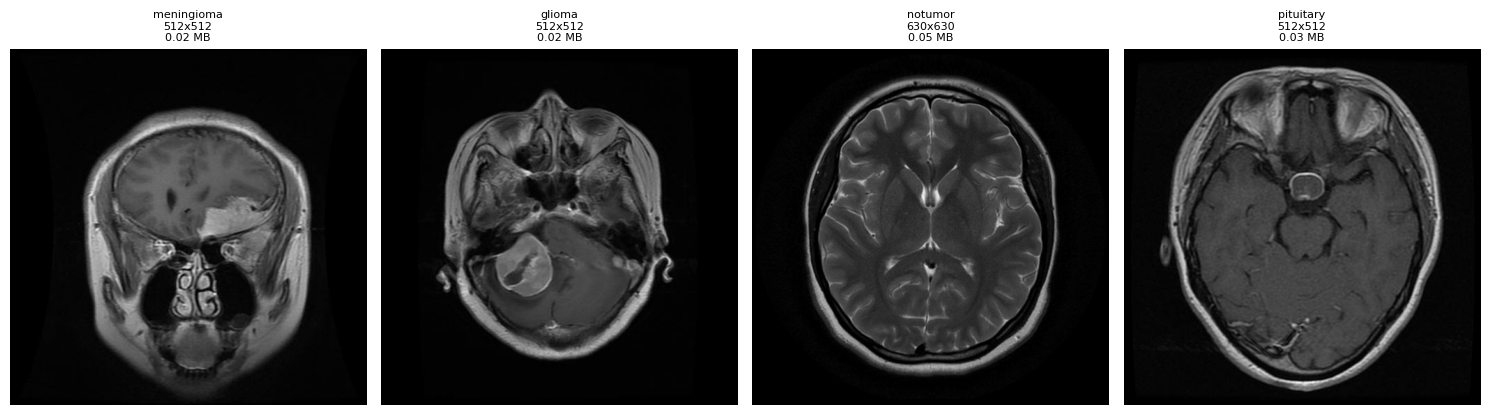

In [8]:
def get_image_details(category, image_path):
    # Open the image
    image = Image.open(image_path)
    # Get image size (width and height)
    width, height = image.size
    # Get image storage size in bytes
    storage_size = os.path.getsize(image_path)
    # Convert storage size to MB
    storage_size_mb = storage_size / (1024 * 1024)
    print(f"Image belongs to {category}. Width: {width}, Height: {height}, Size: {storage_size_mb:.2f} MB\n")
    return image, f"{category}\n{width}x{height}\n{storage_size_mb:.2f} MB"

# Define the test images
test_images = [
    ['meningioma', '/kaggle/input/brain-tumor-mri-dataset/Training/meningioma/Tr-meTr_0000.jpg'],
    ['glioma', '/kaggle/input/brain-tumor-mri-dataset/Training/meningioma/Tr-me_0021.jpg'],
    ['notumor', '/kaggle/input/brain-tumor-mri-dataset/Training/notumor/Tr-no_0011.jpg'],
    ['pituitary', '/kaggle/input/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_0012.jpg']
]

# Plot images in a single row
fig, axes = plt.subplots(1, len(test_images), figsize=(15, 5))
for i, (category, image_path) in enumerate(test_images):
    try:
        image, details = get_image_details(category, image_path)
        axes[i].imshow(image)
        axes[i].set_title(details, fontsize=8)
        axes[i].axis('off')  # Hide axes for better visualization
    except Exception as e:
        print(f"Error processing {category}: {e}")

plt.tight_layout()
plt.show()

# This project name should be taken from the wandb
wandb_project_name = "deep-learning-approaches-for-brain-tumor-detection"
image_size = 224
batch_size = 16
learning_rate = 0.001
epochs_count = 100
num_classes = 4

secret_value_1 = user_secrets.get_secret("wandb_api_key")
# wandb_run wandb
import wandb

<a id="6"></a>
# 6. Image paths stores to array

Brain Tumor Image Training Counts:
╔═══════════════╦═══════════════════════╗
║   Image Count ║  Type of Brain Tumor  ║
╠═══════════════╬═══════════════════════╣
║          1321 ║        Glioma         ║
║          1339 ║      Meningioma       ║
║          1595 ║        Notumor        ║
║          1457 ║       Pituitary       ║
╚═══════════════╩═══════════════════════╝

 Brain Tumor Image Test Counts:
╔═══════════════╦═══════════════════════╗
║   Image Count ║  Type of Brain Tumor  ║
╠═══════════════╬═══════════════════════╣
║           300 ║        Glioma         ║
║           306 ║      Meningioma       ║
║           405 ║        Notumor        ║
║           300 ║       Pituitary       ║
╚═══════════════╩═══════════════════════╝


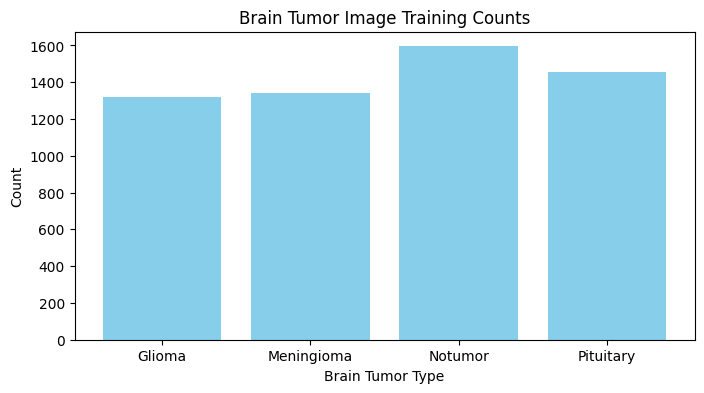

2025-12-27 02:13:25.664619: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-27 02:13:25.664713: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-27 02:13:25.667031: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


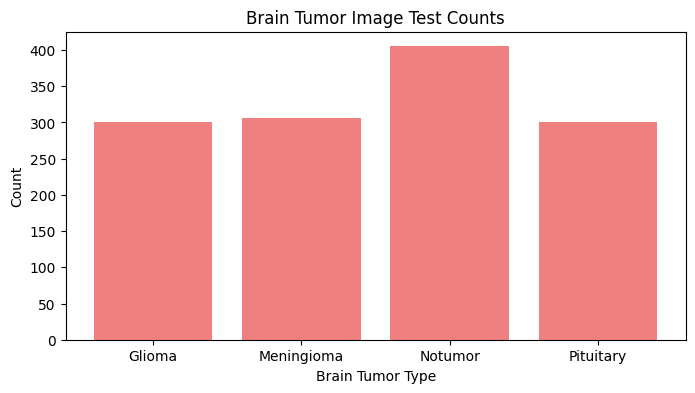

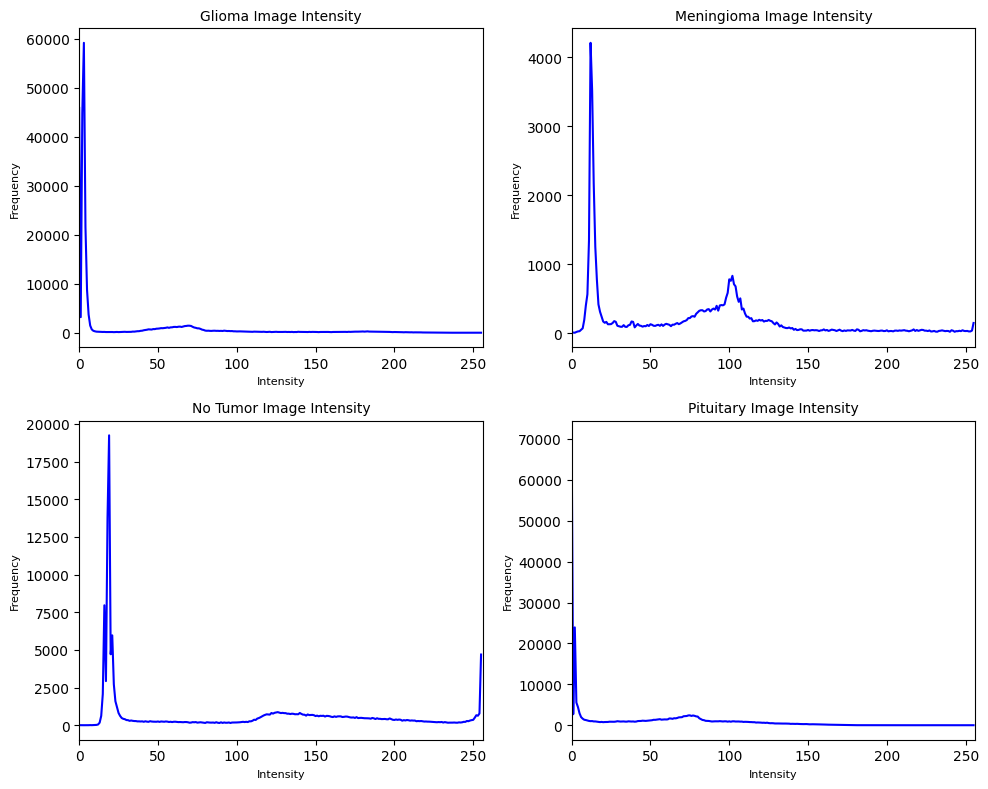

In [9]:
# Image path read function
def read_image_path(return_array_name, path_array):
    for i in path_array:
        folderPath = os.path.join(i)
        for j in os.listdir(folderPath):
            return_array_name.append(os.path.join(folderPath,j))
            
common_mapping_for_path = "/kaggle/input/brain-tumor-mri-dataset/"
# common_mapping_for_path = "/kaggle/input/"
paths_glioma_train = [common_mapping_for_path+"Training/glioma"]
paths_meningioma_train = [common_mapping_for_path+"Training/meningioma"]
paths_notumor_train = [common_mapping_for_path+"Training/notumor"]
paths_pituitarY_train_label = [common_mapping_for_path+"Training/pituitary"]


# read trainingpath similar images to one array 
paths_glioma_images_train = []
read_image_path(paths_glioma_images_train,paths_glioma_train)

paths_meningioma_images_train = []
read_image_path(paths_meningioma_images_train,paths_meningioma_train)

paths_notumor_images_train = []
read_image_path(paths_notumor_images_train,paths_notumor_train)

paths_pituitary_images_train = []
read_image_path(paths_pituitary_images_train,paths_pituitarY_train_label)

count_glioma_images_train = len(paths_glioma_images_train)
count_meningioma_images_train = len(paths_meningioma_images_train)
count_notumor_images_train = len(paths_notumor_images_train)
count_pituitary_images_train = len(paths_pituitary_images_train)

# Create a dictionary to store the data
data = {
    "Type of Brain Tumor": ["Glioma", "Meningioma", "Notumor", "Pituitary"],
    "Image Count": [count_glioma_images_train, count_meningioma_images_train, count_notumor_images_train, count_pituitary_images_train]
}

# Print the data in a tabular format
print("Brain Tumor Image Training Counts:")
table = []
for i in range(len(data["Type of Brain Tumor"])):
    table.append([data['Image Count'][i],data['Type of Brain Tumor'][i]])

headers = ["Image Count", "Type of Brain Tumor"]
print(tabulate(table, headers, tablefmt="double_outline", stralign="center"))   
    

paths_glioma_test = [common_mapping_for_path+"Testing/glioma"]
paths_meningioma_test = [common_mapping_for_path+"Testing/meningioma"]
paths_notumor_test = [common_mapping_for_path+"Testing/notumor"]
paths_pituitarY_test_label = [common_mapping_for_path+"Testing/pituitary"]

# read test path similar images to one array 
paths_glioma_images_test = []
read_image_path(paths_glioma_images_test,paths_glioma_test)

paths_meningioma_images_test = []
read_image_path(paths_meningioma_images_test,paths_meningioma_test)

paths_notumor_images_test = []
read_image_path(paths_notumor_images_test,paths_notumor_test)

paths_pituitary_images_test = []
read_image_path(paths_pituitary_images_test,paths_pituitarY_test_label)


count_glioma_images_test = len(paths_glioma_images_test)
count_meningioma_images_test = len(paths_meningioma_images_test)
count_notumor_images_test = len(paths_notumor_images_test)
count_pituitary_images_test = len(paths_pituitary_images_test)

# Create a dictionary to store the data
data = {
    "Type of Brain Tumor": ["Glioma", "Meningioma", "Notumor", "Pituitary"],
    "Image Count": [count_glioma_images_test, count_meningioma_images_test, count_notumor_images_test, count_pituitary_images_test]
}
    
# Print the data in a tabular format
print("\n Brain Tumor Image Test Counts:")

table = []
for i in range(len(data["Type of Brain Tumor"])):
    table.append([data['Image Count'][i],data['Type of Brain Tumor'][i]])

headers = ["Image Count", "Type of Brain Tumor"]
print(tabulate(table, headers, tablefmt="double_outline", stralign="center"))




# Training data counts
training_data = {"Glioma": count_glioma_images_train, "Meningioma": count_meningioma_images_train, "Notumor": count_notumor_images_train, "Pituitary": count_pituitary_images_train}

# Test data counts
test_data = {"Glioma": count_glioma_images_test, "Meningioma": count_meningioma_images_test, "Notumor": count_notumor_images_test, "Pituitary": count_pituitary_images_test}

# Brain Tumor Image Training Counts
plt.figure(figsize=(8, 4))
plt.bar(training_data.keys(), training_data.values(), color='skyblue')
plt.title("Brain Tumor Image Training Counts")
plt.xlabel("Brain Tumor Type")
plt.ylabel("Count")
plt.show()

# Brain Tumor Image Test Counts
plt.figure(figsize=(8, 4))
plt.bar(test_data.keys(), test_data.values(), color='lightcoral')
plt.title("Brain Tumor Image Test Counts")
plt.xlabel("Brain Tumor Type")
plt.ylabel("Count")
plt.show()

def print_image_intensity(img_path, img_name, ax):
    img = cv2.imread(img_path)
    # Convert the image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Calculate the image intensity histogram
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

    # Plot the histogram in the given axis
    ax.plot(hist, color='blue')
    ax.set_title(f"{img_name} Intensity", fontsize=10)
    ax.set_xlabel("Intensity", fontsize=8)
    ax.set_ylabel("Frequency", fontsize=8)
    ax.set_xlim([0, 256])

# Define images to process
test_images = [
    (paths_glioma_images_test[1], "Glioma Image"),
    (paths_meningioma_images_test[1], "Meningioma Image"),
    (paths_notumor_images_test[1], "No Tumor Image"),
    (paths_pituitary_images_test[1], "Pituitary Image"),
]

# Plot all histograms in 2 rows
fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # 2 rows, 2 columns
axes = axes.flatten()  # Flatten to iterate easily

for i, (img_path, img_name) in enumerate(test_images):
    try:
        print_image_intensity(img_path, img_name, axes[i])
    except Exception as e:
        print(f"Error processing {img_name}: {e}")

plt.tight_layout()
plt.show()


In [10]:
def print_image_from_array(array_name,image_array_name,label_array_name, image_index ):
    image_array_length = len(image_array_name)
    if(image_array_length>image_index):
        print(f"Total images in the {array_name} array : {image_array_length}, given image index is {image_index}")
        plt.title(f"Image labled as {label_array_name[image_index]}")
        plt.imshow(image_array_name[image_index],interpolation='nearest')
        plt.show()
    else:
        print("Given image index is not inside the given image arrays.")


<a id="7"></a>
# 7. Data set creation *Balance* and *imbalanced* 

  0%|          | 0/1321 [00:00<?, ?it/s]

TensorBoard 2.15.1 at http://0.0.0.0:5006/ (Press CTRL+C to quit)


  0%|          | 0/1339 [00:00<?, ?it/s]

  0%|          | 0/1595 [00:00<?, ?it/s]

  0%|          | 0/1457 [00:00<?, ?it/s]

...

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/306 [00:00<?, ?it/s]

  0%|          | 0/405 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

Total images in the test data array : 1311, given image index is 1000


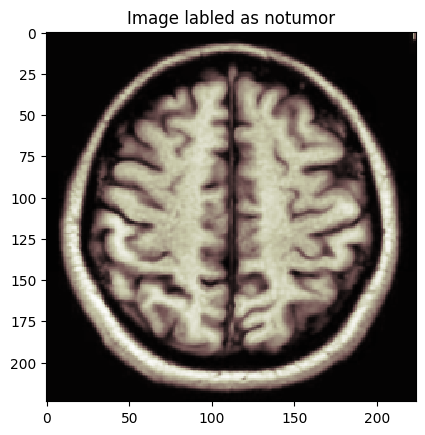

╔══════════════════╦═══════════════╦═══════════════╗
║       Type       ║   Image Count ║   Label Count ║
╠══════════════════╬═══════════════╬═══════════════╣
║  Balance image   ║          5284 ║          5284 ║
║ imbalanced image ║          5712 ║          5712 ║
║    Test image    ║          1311 ║          1311 ║
╚══════════════════╩═══════════════╩═══════════════╝
Total images in the train balance array : 5284, given image index is 1


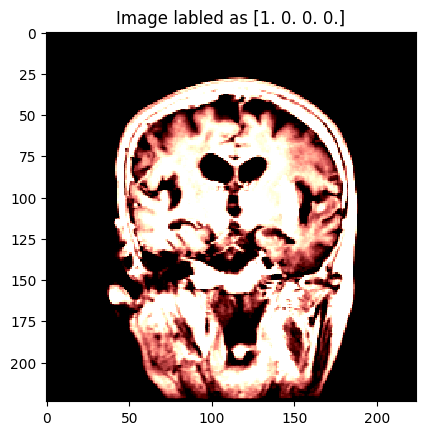

X_train dtype: float32
Y_train_label dtype: float32
x_test dtype: float32
y_test_label dtype: float32


In [11]:
labels = ['glioma','meningioma','notumor','pituitary']


def read_image(image_size, folderPath):
    read_image_values = []
    for j in tqdm(folderPath):
        # Load image in grayscale
        img = cv2.imread(j, cv2.IMREAD_GRAYSCALE)
        # Apply CLAHE to enhance local contrast
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img = clahe.apply(img)
        # Apply bilateral filter to reduce noise
        img = cv2.bilateralFilter(img, d=2, sigmaColor=50, sigmaSpace=50)
        # Convert grayscale to pseudo-colored using COLORMAP_BONE
        img = cv2.applyColorMap(img, cv2.COLORMAP_BONE)
        # Resize to desired dimensions
        img = cv2.resize(img, (image_size, image_size), interpolation=cv2.INTER_AREA)
        # Append processed image
        read_image_values.append(img)
        
    return read_image_values

 
def make_array_with_lable(array, label):
    label_array =[]
    array_length = len(array)
    for i in tqdm(range(array_length)):
        label_array.append(label)
    return label_array    
        
    
read_glioma_image_train = shuffle(read_image(image_size,paths_glioma_images_train),random_state=101)
read_meningioma_image_train = shuffle(read_image(image_size,paths_meningioma_images_train),random_state=101)
read_notumor_image_train = shuffle(read_image(image_size,paths_notumor_images_train),random_state=101)
read_pituitary_image_train = shuffle(read_image(image_size,paths_pituitary_images_train),random_state=101)

read_glioma_label_train = make_array_with_lable(read_glioma_image_train,'glioma')
read_meningioma_label_train = make_array_with_lable(read_meningioma_image_train,'meningioma')
read_notumor_label_train = make_array_with_lable(read_notumor_image_train,'notumor')
read_pituitary_label_train = make_array_with_lable(read_pituitary_image_train,'pituitary')

# image_count = 30
image_count = count_glioma_images_train


# create balance data set 
X_train_imbalanced = read_glioma_image_train+read_meningioma_image_train+read_notumor_image_train+read_pituitary_image_train
Y_train_label_imbalanced = read_glioma_label_train+read_meningioma_label_train+read_notumor_label_train+read_pituitary_label_train


# create balance data set 
X_train_balance = read_glioma_image_train[:image_count]+read_meningioma_image_train[:image_count]+read_notumor_image_train[:image_count]+read_pituitary_image_train[:image_count]
Y_train_label_balance = read_glioma_label_train[:image_count]+read_meningioma_label_train[:image_count]+read_notumor_label_train[:image_count]+read_pituitary_label_train[:image_count]


read_glioma_image_test = shuffle(read_image(image_size,paths_glioma_images_test),random_state=101)
read_meningioma_image_test = shuffle(read_image(image_size,paths_meningioma_images_test),random_state=101)
read_notumor_image_test = shuffle(read_image(image_size,paths_notumor_images_test),random_state=101)
read_pituitary_image_test = shuffle(read_image(image_size,paths_pituitary_images_test),random_state=101)

read_glioma_label_test = make_array_with_lable(read_glioma_image_test,'glioma')
read_meningioma_label_test = make_array_with_lable(read_meningioma_image_test,'meningioma')
read_notumor_label_test = make_array_with_lable(read_notumor_image_test,'notumor')
read_pituitary_label_test = make_array_with_lable(read_pituitary_image_test,'pituitary')


# create balance data set 
x_test = read_glioma_image_test+read_meningioma_image_test+read_notumor_image_test+read_pituitary_image_test
y_test_label = read_glioma_label_test+read_meningioma_label_test+read_notumor_label_test+read_pituitary_label_test

def print_image_from_array(array_name,image_array_name,label_array_name, image_index ):
    image_array_length = len(image_array_name)
    if(image_array_length>image_index):
        print(f"Total images in the {array_name} array : {image_array_length}, given image index is {image_index}")
        plt.title(f"Image labled as {label_array_name[image_index]}")
        plt.imshow(image_array_name[image_index],interpolation='nearest')
        plt.show()
    else:
        print("Given image index is not inside the given image arrays.")
    
print_image_from_array("test data",x_test,y_test_label,1000)

def z_score_per_image(img_array):
    mean = np.mean(img_array, axis=(1, 2, 3), keepdims=True)
    std = np.std(img_array, axis=(1, 2, 3), keepdims=True)
    return (img_array - mean) / (std + 1e-8)  # add epsilon to avoid div-by-zero


# Balance data array convert to numpy array
X_train_balance = z_score_per_image(np.array(X_train_balance, dtype=np.float32))
Y_train_label_balance = np.array(Y_train_label_balance)

  # imbalanced data array convert to numpy array
X_train_imbalanced = z_score_per_image(np.array(X_train_imbalanced, dtype=np.float32))
Y_train_label_imbalanced = np.array(Y_train_label_imbalanced)

 # Test data array convert to numpy array
x_test = z_score_per_image(np.array(x_test, dtype=np.float32))
y_test_label = np.array(y_test_label)


table = [["Balance image",len(X_train_balance),len(Y_train_label_balance)],["imbalanced image",len(X_train_imbalanced),len(Y_train_label_imbalanced)],["Test image",len(x_test),len(y_test_label)]]
headers = ["Type","Image Count", "Label Count"]
print(tabulate(table, headers, tablefmt="double_outline", stralign="center"))

def encode_labels(labels_list, labels_mapping, num_classes=4):
    # Convert string labels to indices
    label_indices = [labels_mapping.index(lbl) for lbl in labels_list]
    # Convert to numpy array
    label_indices = np.array(label_indices)
    # One-hot encode
    one_hot_labels = tf.keras.utils.to_categorical(label_indices, num_classes=num_classes)
    # Cast to float16 for memory efficiency
    return one_hot_labels.astype(np.float32)

# Assuming `labels` is your label mapping list
y_test_label = encode_labels(y_test_label, labels, num_classes=4)
Y_train_label_balance = encode_labels(Y_train_label_balance, labels, num_classes=4)
Y_train_label_imbalanced = encode_labels(Y_train_label_imbalanced, labels, num_classes=4)

print_image_from_array("train balance",X_train_balance,Y_train_label_balance,1)


print("X_train dtype:", X_train_balance.dtype)
print("Y_train_label dtype:", Y_train_label_balance.dtype)
print("x_test dtype:", x_test.dtype)
print("y_test_label dtype:", y_test_label.dtype)


<a id="8"></a>
# 8. Model Training / Data preparation for validation and training 

## 8.1  Model Data Taken

In [12]:
# model summary 
def model_summary_print(model):
    model.summary()
    
# model layers
def model_layers(model):
    for idx in range(len(model.layers)):
        print(f'Name : {model.get_layer(index=idx).name}, \t \t | Shape :  {model.get_layer(index=idx).input_spec}')
        
# get last layer convalution of the model
def get_last_convalutional_layer(model):
    # Iterate through the layers to find the last convolutional layer
    last_conv_layer_name = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer_name = layer.name
            break
    print("Name of the last convolutional layer:", last_conv_layer_name)
    return last_conv_layer_name

# plot model architecture 
def plot_model_png(model, model_name):
    name = f'plot-{model_name}.png'
    plot_model(model, show_shapes=True, show_layer_names=True, to_file=name)
    
# -----========----------------
# model inside info
def count_params(weights):
    total_params = 0
    for w in weights:
        if isinstance(w, tf.keras.layers.Layer):
            total_params += tf.size(w.trainable_weights).numpy()
        else:
            total_params += tf.size(w).numpy()
    return total_params

def model_inside_info(model,model_name):
#     Get the total number of parameters
    total_params = count_params(model.weights)

#     Get the number of trainable parameters
    trainable_params = count_params(model.trainable_weights)

#     Get the number of non-trainable parameters (optional)
    non_trainable_params = count_params(model.non_trainable_weights)

#     Get the number of layers (manual approach)
    num_layers = len(model.layers)
    
    headers = ["Total Parameters","Trainable Parameters", "Number of Layers"]
    table = ['{:.0f}'.format(total_params),'{:.0f}'.format(trainable_params),'{:.0f}'.format(num_layers)]
    
#     Print non-trainable parameters if needed
    if non_trainable_params > 0:
        headers.append("Non-Trainable Parameters")
        table.append('{:.0f}'.format(non_trainable_params))
    
    print(f"Details about model {model_name}")
    for i, header in enumerate(headers):
        print(f'{header} : {table[i]}')
        
    # Get input shape
    input_shape = model.input_shape

    # Get output shape
    output_shape = model.output_shape

    print(f'Input shape: {input_shape}')
    print(f'Output shape: {output_shape}')
    
        # Get weights as numpy arrays
    weights = model.get_weights()

    for i, weights_layer in enumerate(weights):
        print(f'Layer {i}: {weights_layer.shape}')
        
        # Get model configuration as JSON
    model_config = model.get_config()

    # Print or save the model configuration
#     print(model_config)

# model training or not validation
def model_is_trained_or_not(model):
    # Check if any of the layers have non-random weights
    is_trained = False
    for layer in model.layers:
        if layer.trainable_weights:
            is_trained = True
            break

    if is_trained:
        print("The model is trained.")
    else:
        print("The model is not trained or its layers have random weights.")

## 8.2 Training Method Implement 

In [13]:
"""
Classification Models:
Accuracy / Precision / Recall / F1-Score / Confusion Matrix /  ROC AUC (Area Under the ROC Curve) / Classification Report

Regression Models:
Mean Squared Error (MSE) / Root Mean Squared Error (RMSE) / Mean Absolute Error (MAE) / R-squared /
"""

# Define top-k categorical accuracy function
def top_k_categorical_accuracy(Y_test_label, y_pred, k=5):
    return tf.keras.metrics.top_k_categorical_accuracy(Y_test_label, y_pred, k=k)

METRICS = [
    'accuracy',
    'precision', 
    'recall',
#     'categorical_crossentropy',
#     tf.keras.metrics.LogCoshError(),
#     tf.keras.metrics.Poisson(),
#     'cosine_similarity',
#     'mean_squared_error',
#     'mean_absolute_error',
#     top_k_categorical_accuracy,
#     'mean_absolute_percentage_error',
#     tf.keras.metrics.RootMeanSquaredError()
]



def model_training_validation(model,created_model_name,X_train,Y_train_label,x_test,y_test_label):

    print('taining model inside details ', created_model_name,'\n')
#     model_inside_info(model,created_model_name)
#     model_layers(model)
#     model_summary_print(created_model_name)
    
    print('taining model status', created_model_name,'\n')
    
    print('---------- model compile ------------')
    model.compile(loss='categorical_crossentropy',
                  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  metrics=METRICS)
#     model.compile(loss='categorical_crossentropy',optimizer='Adam', metrics=METRICS)
    
    print('---------- model checkpoint callback ------------')
    filepath = 'propose.{epoch:03d}.keras'
    checkpoint = ModelCheckpoint(filepath=filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
    
    # Define the EarlyStopping callback
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True)
    
    # Define the ReduceLROnPlateau callback with validation accuracy as the monitoring metric
    reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=5, verbose=1)

    print('---------- tensorboard callback ------------')
    log_dir = f"logs/{created_model_name}-i-s_{image_size}-e-c_{epochs_count}"  + getNowDateTime()
    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)


    print('---------- wandb callback start after loggin ------------')
    wandb.login(key=secret_value_1) 
#     wandb.tensorboard.patch(root_logdir="./logs/")
    name_wandb = f'{created_model_name}-img-size_{image_size}-{epochs_count}_epochs-{getNowDateTime()}-learning_rate-{learning_rate}-model'
    
   
    wandb_run = wandb.init(entity = 'lalithk90', 
                     project=wandb_project_name, 
                     sync_tensorboard=False, 
                     name=name_wandb)
    
    print('---------- wandb callback start after loggin ------------')
    get_model_inside_and_traing_data(model, name_wandb)
    
    print('---------- model start to fit ------------')
    history=model.fit(X_train, 
                      Y_train_label, 
                      epochs=epochs_count, 
                      batch_size=batch_size, 
                      validation_data= (x_test, y_test_label), 
                      callbacks=[checkpoint,tensorboard_callback,early_stopping,reduce_lr],
                      verbose=0
                     )

   
    name = 'save-'+name_wandb+'.h5'
    model.save(name)
    
    print(f'---------- model saved name:- {name}------------')
    
    artifact = wandb.Artifact(name=name, type="dataset")

    # Add a file to the artifact's contents
    artifact.add_file(local_path="/kaggle/working/"+name)

    # Save the artifact version to W&B and mark it as the output of this wandb_wandb_run
    wandb_run.log_artifact(artifact)
    
    wandb.finish()
    
    print('---------- call model training history visualization ------------')
    # model_history_visualization(history)
    
    print('---------- call model validation ------------')
    # model_evaluation(model,x_test,y_test_label,name_wandb)
    
    print('---------- call model prediction ------------')
    # prediction(model, name_wandb)


    print('---------- model xai validation ------------')
    xai_validate_model(
    model=model,
    images=x_test,
    labels=y_test_label,
    conv_layer=get_last_convalutional_layer(model),
    title=name_wandb+" – XAI Evaluation")

    delete_keras_files(name)

def delete_keras_files(created_model_name):
# Delete all .keras checkpoint files
        keras_files = glob.glob(f'propose_{created_model_name}_*.keras')
        for keras_file in keras_files:
            try:
                os.remove(keras_file)
                print(f'Deleted checkpoint file: {keras_file}')
            except OSError as e:
                print(f'Error deleting {keras_file}: {e}')

<a id="9"></a>
# 9. Model history visulization

In [14]:
def draw_plot(accuracy,validation_accuracy,validation_label,validation_accuracy_label, plot_title ):
    epochs = range(len(accuracy))
    fig = plt.figure(figsize=(8,4))
    plt.title(plot_title)
    plt.xticks(np.arange(0, len(accuracy), 10))
    plt.plot(epochs,accuracy,'r', label=validation_label, marker="o")
    plt.plot(epochs,validation_accuracy,'b', label=validation_accuracy_label, marker="*")
    plt.legend(loc='upper left')
#     plt.savefig('Multiclass Model .png')
    plt.figure()
    plt.show()
    
def model_history_visualization(history):
    accuracy = history.history['accuracy']
    epochs = range(0,len(accuracy))
    
    draw_plot(accuracy, history.history['val_accuracy'], 'accuracy','val_accuracy','Training and Validation Accuracy')
    draw_plot(history.history['loss'], history.history['val_loss'], 'loss','val_loss', 'Training and Validation Loss')
    draw_plot(history.history['precision'], history.history['val_precision'], 'precision','val_precision', 'Training and Validation Precision')
    draw_plot(history.history['recall'],  history.history['val_recall'], 'recall','val_recall','Training and Validation Recall')
    #     draw_plot(history.history['mean_squared_error'], history.history['val_mean_squared_error'], 'mean_squared_error','val_mean_squared_error', 'Training and Validation Mean_squared_error')
#     draw_plot(history.history['mean_absolute_error'], history.history['val_mean_absolute_error'], 'mean_absolute_error','val_mean_absolute_error', 'Training and Validation Mean_absolute_error')
#     draw_plot(history.history['mean_absolute_percentage_error'], history.history['val_mean_absolute_percentage_error'], 'mean_absolute_percentage_error','val_mean_absolute_percentage_error', 'Training and Validation Mean_absolute_percentage_error')
#     draw_plot(history.history['cosine_similarity'], history.history['val_cosine_similarity'], 'cosine_similarity','val_cosine_similarity', 'Training and Validation Cosine_similarity')
#     draw_plot(history.history['categorical_crossentropy'], history.history['val_categorical_crossentropy'], 'categorical_crossentropy','val_categorical_crossentropy','Training and Validation Categorical_crossentropy')
#     draw_plot(history.history['top_k_categorical_accuracy'], history.history['val_top_k_categorical_accuracy'], 'top_k_categorical_accuracy','val_top_k_categorical_accuracy', 'Training and Validation Top_k_categorical_accuracy')
#     draw_plot(history.history['logcosh'], history.history['val_logcosh'], 'log_cosh_error','val_log_cosh_error', 'Training and Validation Log_cosh_error')
#     draw_plot(history.history['poisson'], history.history['val_poisson'], 'poisson','val_poisson', 'Training and Validation Poisson')
#     draw_plot(history.history['root_mean_squared_error'], history.history['val_root_mean_squared_error'], 'root_mean_squared_error','val_root_mean_squared_error', 'Training and Validation Root_mean_squared_error')
    print('---------- end model training history visualization ------------')

<a id="10"></a>
# 10. Model Evaluation

In [15]:
def model_evaluate(model, X_test,Y_test_label,model_name):
#     ------------------------- start ----------------
    score = model.evaluate(X_test,Y_test_label)
    print(f'{model_name}')
    
    headers = ["Test loss","Test accuracy","Test loss(%)","Test accuracy(%)"]
    table = [[score[0],score[1],(score[0]*100),(score[1]*100)]]
    print(tabulate(table, headers, tablefmt="double_outline", stralign="center"))
   #     ------------------------- end ---------------- 
   
def visualize_confusion_matrix(cm,model_name):
    #     ------------------------- start ----------------
    # Visualize confusion matrix (optional)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.savefig(f"{model_name}_confusion_matrix.png")  # Save the plot as an image
    plt.show()
    #     ------------------------- end ----------------
    
def model_sensitivity(Y_test_label, cm, y_pred, model_name ):
#     ------------------------- start ----------------
    # Sensitivity = True Positives/ (True Positives + True Negatives)
    # Calculate sensitivity for each class
    classes = np.unique(Y_test_label)
    sensitivities = {}
    for c in classes:
        tp = cm[c, c]
        fn = np.sum(cm[c, :]) - tp
        sensitivities[c] = tp / (tp + fn)

    # Find the modal sensitivity
    modal_sensitivity = max(sensitivities, key=sensitivities.get)

    # Assuming `Y_test_label` are your true labels and `y_pred` are your predicted labels
    res = []
    for l in np.unique(Y_test_label):
        prec, recall, _, _ = precision_recall_fscore_support(Y_test_label == l, y_pred == l, pos_label=True, average=None)
        res.append([l, recall[0]])

    # Convert to DataFrame for easier manipulation
    df = pd.DataFrame(res, columns=['class', 'sensitivity'])

    # Calculate the average sensitivity
    average_sensitivity = df['sensitivity'].mean()

    print(f"{model_name} Sensitivities")
    
    headers = ["Label","Sensitivities"]
    table = []
    for i in range(len(sensitivities)):
        table.append([labels[i],sensitivities[i]])
    print(tabulate(table, headers, tablefmt="double_outline", stralign="center"))
    
    headers = ["Modal Sensitivity","Modal Average Sensitivity"]
    table = [[modal_sensitivity,average_sensitivity]]
    print(tabulate(table, headers, tablefmt="double_outline", stralign="center"))
    
    #     ------------------------- end ----------------
    
def model_specificity(cm,model_name):
#     ------------------------- start ----------------
    # Specificity = True Negatives/ (False Positives + True Negatives)

    # Calculate specificity for each class
    FP = cm.sum(axis=0) - np.diag(cm) # False positives
    FN = cm.sum(axis=1) - np.diag(cm) # False negatives
    TN = cm.sum() - (FP + FN + np.diag(cm)) # True negatives

    Specificity = TN / (TN + FP)
        
    headers = ["Label", "Specificity"]
    table = []
    # Print specificity for each class
    for i, spec in enumerate(Specificity):
        table.append([labels[i],spec])
        
    print(f"Specificity {model_name}")
    print(tabulate(table, headers, tablefmt="double_outline", stralign="center"))    
    #     ------------------------- end ----------------
    
def model_roc_auc(Y_test_label,predictions,model_name):
#     ------------------------- start ----------------
    # Calculate ROC AUC score for each class against all other classes
    roc_auc = roc_auc_score(Y_test_label, predictions, multi_class='ovr')
    # Calculate ROC AUC score for each pair of classes
    roc_auc = roc_auc_score(Y_test_label, predictions, multi_class='ovo')

    print(f"ROC AUC Score {model_name} ")
    headers = ["ROC AUC Score (OvR) -> One-vs-Rest","ROC AUC Score (OvO) -> One-vs-One"]
    table = [[roc_auc,roc_auc]]
    print(tabulate(table, headers, tablefmt="double_outline", stralign="center"))   
    
    print("\n The area under the ROC curve (AUC) results were considered")
           
    headers = ["Model Status","Result Range"]
    table = [["excellent","AUC values between 0.9 - 1 "],["good"," AUC values between 0.8-0.9 "],["fair" , "AUC values between 0.7-0.8 "],["poor" , "AUC values between 0.6-0.7 "],["failed" , "AUC values between 0.5-0.6"]]
    print(tabulate(table, headers, tablefmt="double_outline", stralign="center"))
    
    #     ------------------------- end ----------------

def model_accuracy_score(Y_test_label, y_pred, model_name):
#     ------------------------- start ----------------
    ac_s_without_normalize = accuracy_score(Y_test_label, y_pred)
    ac_s_with_normalize = accuracy_score(Y_test_label, y_pred, normalize=False)
    print(f'Model Accuracy Score {model_name}')
    headers = ["Accuracy score without normalize","Accuracy score with normalize"]
    table = [[ac_s_without_normalize,ac_s_with_normalize]]
    print(tabulate(table, headers, tablefmt="double_outline", stralign="center")) 
    
    #     ------------------------- end ----------------
    
def model_balanced_accuracy(Y_test_label, y_pred, model_name):
#     ------------------------- start ----------------
    balanced_accuracy_s = balanced_accuracy_score(Y_test_label, y_pred)
    
    print(f'Model Balanced Score {model_name}')
    headers = ["Balanced accuracy score"]
    table = [[balanced_accuracy_s]]
    print(tabulate(table, headers, tablefmt="double_outline", stralign="center")) 
    #     ------------------------- end ----------------
    
def model_cohen_kappa_score(Y_test_label, y_pred, model_name):
#     ------------------------- start ----------------
    cohen_kappa_score_test = cohen_kappa_score(Y_test_label, y_pred)
    
    print(f'Cohen\'s Kappa Score {model_name}')
    headers = ["Cohen\'s Kappa Score"]
    table = [[cohen_kappa_score_test]]
    print(tabulate(table, headers, tablefmt="double_outline", stralign="center")) 
    #     ------------------------- end ----------------    
        
def model_matthews_corrcoef(Y_test_label, y_pred, model_name):
#     ------------------------- start ----------------
    matthews_corrcoef_test = matthews_corrcoef(Y_test_label, y_pred)
    
    print(f'matthews_corrcoef Score {model_name}')
    headers = ["matthews_corrcoef Score"]
    table = [[matthews_corrcoef_test]]
    print(tabulate(table, headers, tablefmt="double_outline", stralign="center")) 
    #     ------------------------- end ----------------   
    
def model_log_loss(Y_test_label, predictions, model_name):
#     ------------------------- start ----------------
    log_loss_test = log_loss(Y_test_label, predictions)
    
    print(f'Model Log loss {model_name}')
    headers = ["Log loss"]
    table = [[log_loss_test]]
    print(tabulate(table, headers, tablefmt="double_outline", stralign="center")) 
    #     ------------------------- end ----------------  
    
def model_categorical_accuracy(Y_test_label, y_pred, model_name):   
    #------------------------- start ----------------
    m = tf.keras.metrics.categorical_accuracy(Y_test_label, y_pred)
    print(m)
    print(f'Categorical accuracy: {m:.4f}')
    print(f'Categorical accuracy {model_name}')
#     headers = ["Categorical accuracy"]
#     table = [[m]]
#     print(table)
#     print(tabulate(table, headers, tablefmt="double_outline", stralign="center")) 
    #------------------------- end ----------------
    
def model_classification_report(Y_test_label, y_pred, model_name):
        print(f"Classification Report : {model_name}")
        classification_report_values = classification_report(Y_test_label, y_pred, output_dict=True,target_names = labels)


def model_precision_score(Y_test_label, y_pred, model_name):
    print(f"{model_name} Precision score \n ===================================================\n")
#     ------------------------- start ----------------
    precision_score_1 = precision_score(Y_test_label, y_pred, average=None)
    
    headers = ["Label", "Precision score"]
    table = []
    # Print specificity for each class
    for i, score in enumerate(precision_score_1):
        table.append([labels[i],score])

    print(tabulate(table, headers, tablefmt="double_outline", stralign="center"))

    precision_score_macro = precision_score(Y_test_label, y_pred, average='macro')
    precision_score_micro = precision_score(Y_test_label, y_pred, average='micro')
    precision_score_weighted = precision_score(Y_test_label, y_pred, average='weighted')
    
    headers = ["Precision score macro","Precision score micro","Precision score weighted"]
    table = [[precision_score_macro,precision_score_micro,precision_score_weighted]]
    print(tabulate(table, headers, tablefmt="double_outline", stralign="center")) 


    data = {'Micro': precision_score_macro, 'Macro': precision_score_micro, 'Weighted': precision_score_weighted}
    values = list(data.keys())
    results = list(data.values())

    fig = plt.figure(figsize=(10, 5))
    # creating the bar plot
    plt.bar(values, results, color='maroon', width=0.4)
    plt.xlabel('Value', fontweight='bold', fontsize=15)
    plt.ylabel('Various scores', fontweight='bold', fontsize=15)
    plt.title(f"{model_name} Various precision scores according to average")
    plt.savefig(f"{model_name}_Precision_score.png")  # Save the plot as an image
    plt.show()
        #     ------------------------- end ----------------
        
def model_recall_score(Y_test_label, y_pred, model_name):
    print(f"{model_name} Recall score \n ===================================================\n")
    #     ------------------------- start ----------------
    recall_score_1 = recall_score(Y_test_label, y_pred, average=None)
    
    headers = ["Label", "Recall score"]
    table = []
    # Print specificity for each class
    for i, score in enumerate(recall_score_1):
        table.append([labels[i],score])

    print(tabulate(table, headers, tablefmt="double_outline", stralign="center"))
    
    recall_score_macro = recall_score(Y_test_label, y_pred, average='macro')
    recall_score_micro = recall_score(Y_test_label, y_pred, average='micro')
    recall_score_weighted = recall_score(Y_test_label, y_pred, average='weighted')

    headers = ["Recall score macro","Recall score micro","Recall score weighted"]
    table = [[recall_score_macro,recall_score_micro,recall_score_weighted]]
    print(tabulate(table, headers, tablefmt="double_outline", stralign="center")) 

    data = {'Micro': recall_score_macro, 'Macro': recall_score_micro, 'Weighted': recall_score_weighted}
    values = list(data.keys())
    results = list(data.values())

    fig = plt.figure(figsize=(10, 5))
    # creating the bar plot
    plt.bar(values, results, color='blue', width=0.4)

    plt.xlabel('Value', fontweight='bold', fontsize=15)
    plt.ylabel('Various scores', fontweight='bold', fontsize=15)
    plt.title(f"{model_name} Various recall scores according to average")
    plt.savefig(f"{model_name}_recall_score.png")  # Save the plot as an image
    plt.show()
    
#     ------------------------- end ----------------
        
def model_f1_score(Y_test_label, y_pred, model_name):
    print(f"{model_name} F1 score \n ===================================================\n")
    #     ------------------------- start ----------------
    f1_score_1 = f1_score(Y_test_label, y_pred, average=None)
    
    headers = ["Label", "F1 score"]
    table = []
    # Print specificity for each class
    for i, score in enumerate(f1_score_1):
        table.append([labels[i],score])

    print(tabulate(table, headers, tablefmt="double_outline", stralign="center"))
    
    f1_score_macro = f1_score(Y_test_label, y_pred, average='macro')
    f1_score_micro = f1_score(Y_test_label, y_pred, average='micro')
    f1_score_weighted = f1_score(Y_test_label, y_pred, average='weighted')

    headers = ["F1 score macro","F1 score micro","F1 score weighted"]
    table = [[f1_score_macro,f1_score_micro,f1_score_weighted]]
    print(tabulate(table, headers, tablefmt="double_outline", stralign="center")) 

    data = {'Micro': f1_score_macro, 'Macro': f1_score_micro,'Weighted': f1_score_weighted}
    values = list(data.keys())
    results = list(data.values())

    fig = plt.figure(figsize=(10, 5))
    # creating the bar plot
    plt.bar(values, results, color='green',width=0.4)
    
    plt.xlabel('Value', fontweight='bold', fontsize=15)
    plt.ylabel('Various scores', fontweight='bold', fontsize=15)
    plt.title(f"{model_name} Various F1 scores according to average")
    plt.savefig(f"{model_name}_f1_score.png")  # Save the plot as an image
    plt.show()
        #     ------------------------- end ----------------

In [16]:
def model_evaluation(model, X_test,Y_test_label,model_name):
    
    print('-----------start to call some validation ------------')
    model_evaluate(model, X_test,Y_test_label,model_name)
    
         # Predict the classes
    predictions = model.predict(X_test)

    y_pred = np.argmax(predictions, axis=1)
    Y_test_label= np.argmax(Y_test_label, axis=1)

    cm = confusion_matrix(Y_test_label, y_pred)
    
    visualize_confusion_matrix(cm, model_name)
    model_sensitivity(Y_test_label, cm, y_pred, model_name)
    model_specificity(cm, model_name)
    model_roc_auc(Y_test_label, predictions, model_name)
    model_accuracy_score(Y_test_label, y_pred, model_name)
    model_balanced_accuracy(Y_test_label, y_pred, model_name)
    model_categorical_accuracy(Y_test_label, y_pred, model_name)
    model_precision_score(Y_test_label, y_pred, model_name)
    model_recall_score(Y_test_label, y_pred, model_name)
    model_f1_score(Y_test_label, y_pred, model_name)
    model_classification_report(Y_test_label, y_pred, model_name)
    model_cohen_kappa_score(Y_test_label, y_pred, model_name)
    model_matthews_corrcoef(Y_test_label, y_pred, model_name)
    model_log_loss(Y_test_label, predictions, model_name)

# 11. XAI Validation


In [17]:
import numpy as np
import tensorflow as tf
import cv2
from sklearn.metrics import auc
from lime import lime_image

# =========================
# Utility functions
# =========================

def normalize_heatmap(hm):
    hm = np.maximum(hm, 0)
    return (hm - hm.min()) / (hm.max() - hm.min() + 1e-8)

def resize_to_input(hm, target_shape):
    return cv2.resize(hm, target_shape, interpolation=cv2.INTER_LINEAR)

def binarize_heatmap(hm, top_percent=15):
    thresh = np.percentile(hm, 100 - top_percent)
    return (hm >= thresh).astype(np.uint8)

def dice_score(m1, m2):
    inter = np.sum(m1 * m2)
    return (2 * inter) / (np.sum(m1) + np.sum(m2) + 1e-8)

def iou_score(m1, m2):
    inter = np.sum(m1 * m2)
    union = np.sum(m1) + np.sum(m2) - inter
    return inter / (union + 1e-8)

# =========================
# Explanation generators
# =========================

def generate_gradcam(model, image, class_idx, conv_layer):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(conv_layer).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(image[None])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam = tf.reduce_sum(conv_out[0] * weights, axis=-1)

    cam = normalize_heatmap(cam.numpy())
    cam = resize_to_input(cam, image.shape[:2])  # 🔥 CRITICAL FIX
    return cam

def generate_saliency(model, image, class_idx):
    image_tf = tf.convert_to_tensor(image[None])
    with tf.GradientTape() as tape:
        tape.watch(image_tf)
        preds = model(image_tf)
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, image_tf)[0]
    saliency = tf.reduce_max(tf.abs(grads), axis=-1)
    return normalize_heatmap(saliency.numpy())

def generate_lime_heatmap(model, image, samples=1000):
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        image.astype(np.double),
        classifier_fn=lambda x: model.predict(x),
        top_labels=1,
        hide_color=0,
        num_samples=samples
    )

    _, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        hide_rest=False
    )

    return normalize_heatmap(mask.astype(float))

# =========================
# Faithfulness metrics
# =========================

def comprehensiveness(model, img, mask, cls):
    p0 = model.predict(img[None], verbose=0)[0, cls]
    perturbed = img.copy()
    perturbed[mask == 1] = 0
    p1 = model.predict(perturbed[None], verbose=0)[0, cls]
    return p0 - p1

def sufficiency(model, img, mask, cls):
    p0 = model.predict(img[None], verbose=0)[0, cls]
    kept = np.zeros_like(img)
    kept[mask == 1] = img[mask == 1]
    p1 = model.predict(kept[None], verbose=0)[0, cls]
    return p0 - p1

def deletion_auc(model, img, heatmap, cls, steps=20):
    flat = heatmap.flatten()
    order = np.argsort(flat)[::-1]
    img_flat = img.reshape(-1, img.shape[-1])
    scores = []

    for i in np.linspace(0, len(order), steps).astype(int):
        temp = img_flat.copy()
        temp[order[:i]] = 0
        p = model.predict(temp.reshape(img.shape)[None], verbose=0)[0, cls]
        scores.append(p)

    return auc(range(len(scores)), scores)

def insertion_auc(model, img, heatmap, cls, steps=20):
    flat = heatmap.flatten()
    order = np.argsort(flat)[::-1]
    baseline = np.zeros_like(img).reshape(-1, img.shape[-1])
    orig = img.reshape(-1, img.shape[-1])
    scores = []

    for i in np.linspace(0, len(order), steps).astype(int):
        baseline[order[:i]] = orig[order[:i]]
        p = model.predict(baseline.reshape(img.shape)[None], verbose=0)[0, cls]
        scores.append(p)

    return auc(range(len(scores)), scores)

# =========================
# Uncertainty & calibration
# =========================

def softmax_entropy(p):
    return -np.sum(p * np.log(p + 1e-8))

def prediction_margin(p):
    top2 = np.sort(p)[-2:]
    return top2[1] - top2[0]

def brier_score(p, y_true):
    if isinstance(y_true, (list, np.ndarray)):
        y_true = int(np.argmax(y_true)) 

    y = np.zeros_like(p)
    y[y_true] = 1
    return np.sum((p - y) ** 2)


def mc_dropout(model, img, T=30):
    preds = np.array([
        model(img[None], training=True).numpy()[0]
        for _ in range(T)
    ])
    return preds.mean(axis=0), preds.var(axis=0)

# =========================
# Sanity check
# =========================

def randomized_weights_test(model, img, conv_layer):
    original = generate_gradcam(model, img, 0, conv_layer)

    for layer in model.layers:
        if hasattr(layer, 'kernel'):
            layer.kernel.assign(tf.random.normal(layer.kernel.shape))
            break

    randomized = generate_gradcam(model, img, 0, conv_layer)
    return np.corrcoef(original.flatten(), randomized.flatten())[0, 1]



In [18]:
from tabulate import tabulate
import numpy as np

# =========================
# MAIN VALIDATION FUNCTION
# =========================
def xai_validate_model(model, images, labels, conv_layer, max_samples=30, title="XAI Metrics"):
    results = []

    for img, y in zip(images[:max_samples], labels[:max_samples]):
        probs = model.predict(img[None], verbose=0)[0]
        cls = probs.argmax()

        # -------- Explanations --------
        gc = generate_gradcam(model, img, cls, conv_layer)
        sm = generate_saliency(model, img, cls)
        lm = generate_lime_heatmap(model, img)

        gc_m = binarize_heatmap(gc)
        sm_m = binarize_heatmap(sm)
        lm_m = binarize_heatmap(lm)

        top3 = np.sort(probs)[-3:]

        results.append([
            dice_score(gc_m, lm_m),        # Grad-CAM vs LIME Dice
            iou_score(gc_m, lm_m),         # Grad-CAM vs LIME IoU
            dice_score(gc_m, sm_m),        # Grad-CAM vs Saliency Dice
            iou_score(gc_m, sm_m),         # Grad-CAM vs Saliency IoU
            comprehensiveness(model, img, gc_m, cls),
            sufficiency(model, img, gc_m, cls),
            deletion_auc(model, img, gc, cls),
            insertion_auc(model, img, gc, cls),
            brier_score(probs, y),
            softmax_entropy(probs),
            prediction_margin(probs),
            mc_dropout(model, img)[1].mean(),
            top3[0],                       # Top-3 (lowest)
            top3[1],                       # Top-3 (middle)
            top3[2],                       # Top-3 (highest)
            randomized_weights_test(model, img, conv_layer)
        ])

    mean_metrics = np.nanmean(results, axis=0)

    headers = [
        "Dice (GC vs LIME)",
        "IoU (GC vs LIME)",
        "Dice (GC vs Saliency)",
        "IoU (GC vs Saliency)",
        "Comprehensiveness",
        "Sufficiency",
        "Deletion AUC",
        "Insertion AUC",
        "Brier Score",
        "Softmax Entropy",
        "Prediction Margin",
        "MC Dropout Variance",
        "Top-3 Prob (3rd)",
        "Top-3 Prob (2nd)",
        "Top-3 Prob (1st)",
        "Randomized Weights Corr."
    ]


    print(f"\n{title}")
    print(tabulate([mean_metrics], headers=headers, tablefmt="grid"))


# 12. Print Current Model Inside Info And Training data 

In [19]:
def create_image_to_test(img_path, image_size):
    # Load image in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        # Apply CLAHE to enhance local contrast
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
        # Apply bilateral filter to reduce noise
    img = cv2.bilateralFilter(img, d=2, sigmaColor=50, sigmaSpace=50)
        # Convert grayscale to pseudo-colored using COLORMAP_BONE
    img = cv2.applyColorMap(img, cv2.COLORMAP_BONE)
        # Resize to desired dimensions
    img = cv2.resize(img, (image_size, image_size), interpolation=cv2.INTER_AREA)
    return img

    
def z_score_per_image(img_array):
    mean = np.mean(img_array, axis=(1, 2, 3), keepdims=True)
    std = np.std(img_array, axis=(1, 2, 3), keepdims=True)
    return (img_array - mean) / (std + 1e-8)  # add epsilon to avoid div-by-zero

def prediction(model, model_name):
    print('prediction related to ', model_name)
    x = "/kaggle/input/brain-tumor-mri-dataset/Testing/glioma/Te-glTr_0005.jpg"
    y = "/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma/Te-me_0016.jpg"
    x = "/kaggle/input/brain-tumor-mri-dataset/Testing/pituitary/Te-piTr_0003.jpg"
    i="/kaggle/input/brain-tumor-mri-dataset/Training/notumor/Tr-noTr_0004.jpg"
    j="/kaggle/input/brain-tumor-mri-dataset/Training/glioma/Tr-gl_0014.jpg"
    k="/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma/Te-me_0027.jpg"
    l="/kaggle/input/brain-tumor-mri-dataset/Testing/notumor/Te-no_0029.jpg"
    m="/kaggle/input/brain-tumor-mri-dataset/Training/glioma/Tr-gl_0014.jpg"
    n="/kaggle/input/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_0015.jpg"
    
    image_paths = [x,y,x,i,j,k,l,m,n]
    actual_test_val =['glioma','meningioma','pituitary','notumor','glioma','meningioma','notumor','glioma','pituitary']
    table = []
    # Iterate over the image paths and display each image
    for i, image_path in enumerate(image_paths):
        img_array = create_image_to_test(image_path)
        
        pred_ = model.predict(z_score_per_image(img_array))
        preds = np.squeeze(pred_)
        predict_label = labels[pred_.argmax()]
        actual_label = actual_test_val[i]
        
        table.append([actual_label,predict_label])
        
        title = f'Prediction label : {predict_label} Actual Labeled : {actual_label}\n _________________________________________\n Result related all classes '
        for k in range(len(labels)):
            title = title + f'\n {labels[k]} -----> {preds[k]} '
        img_l = image.load_img(image_path)
        plt.imshow(img_l,interpolation='nearest')
        plt.title(title)
        plt.show() 
        
    headers = ["Actual Test Label","Predict Label"]
    print(tabulate(table, headers, tablefmt="double_outline", stralign="center"))       

In [20]:
def get_model_inside_and_traing_data(model, model_name):    
    print(f'--- Trainned model data - {model_name} ---')
    model_is_trained_or_not(model)
    model_layers(model)
    model_inside_info(model, model_name)
    model_summary_print(model)
    plot_model_png(model, model_name)
    
    headers = ["Image size","Learning rate","Wandb project name","Batch size","Epochs count","Num classes"]
    table = [[image_size,learning_rate,wandb_project_name,batch_size,epochs_count,num_classes]]
    print(tabulate(table, headers, tablefmt="double_outline", stralign="center")) 

In [21]:
import warnings
warnings.filterwarnings('ignore')

# 13 Model Training loop

## 13.1  Proposed Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, Activation,MaxPooling2D, Flatten, Dense, Dropout)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

def propose_model(image_size, num_classes=4):
    inputs = Input(shape=(image_size, image_size, 3))

    # Conv Block 1
    x = Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2(0.001))(inputs)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = MaxPooling2D()(x)

    # Conv Block 2
    x = Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = MaxPooling2D()(x)

    # Conv Block 3
    x = Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = MaxPooling2D()(x)

    # Conv Block 4
    x = Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = MaxPooling2D()(x)

    # Conv Block 5
    x = Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = MaxPooling2D()(x)

    # Flatten + Classification Head
    x = Flatten()(x)
    x = Dense(256, activation='swish', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='swish', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs,  name="propose")
    
model = propose_model(image_size)

model_name = model.name
print(f"Model Start to train: ",model_name)
    
balance_model = model_name+"_balance_propose"
model_training_validation(model,balance_model,X_train_balance,Y_train_label_balance,x_test,y_test_label)
   

imbalanced_model = model_name+"_imbalanced_propose"
model_training_validation(model,imbalanced_model,X_train_imbalanced,Y_train_label_imbalanced,x_test,y_test_label)

Model Start to train:  propose
taining model inside details  propose_balance_propose 

taining model status propose_balance_propose 

---------- model compile ------------
---------- model checkpoint callback ------------
---------- tensorboard callback ------------
---------- wandb callback start after loggin ------------


wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: lalithk90. Use `wandb login --relogin` to force relogin


---------- wandb callback start after loggin ------------
--- Trainned model data - propose_balance_propose-img-size_224-100_epochs-2025-12-27-07-45-10-learning_rate-0.001-model ---
The model is trained.
Name : input_layer, 	 	 | Shape :  None
Name : conv2d, 	 	 | Shape :  InputSpec(min_ndim=4, axes={-1: 3})
Name : batch_normalization, 	 	 | Shape :  InputSpec(ndim=4, axes={-1: 32})
Name : activation, 	 	 | Shape :  None
Name : max_pooling2d, 	 	 | Shape :  InputSpec(ndim=4)
Name : conv2d_1, 	 	 | Shape :  InputSpec(min_ndim=4, axes={-1: 32})
Name : batch_normalization_1, 	 	 | Shape :  InputSpec(ndim=4, axes={-1: 64})
Name : activation_1, 	 	 | Shape :  None
Name : max_pooling2d_1, 	 	 | Shape :  InputSpec(ndim=4)
Name : conv2d_2, 	 	 | Shape :  InputSpec(min_ndim=4, axes={-1: 64})
Name : batch_normalization_2, 	 	 | Shape :  InputSpec(ndim=4, axes={-1: 128})
Name : activation_2, 	 	 | Shape :  None
Name : max_pooling2d_2, 	 	 | Shape :  InputSpec(ndim=4)
Name : conv2d_3, 	 	 | Shape 

Model: "propose"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

...

---------- call model training history visualization ------------
---------- call model validation ------------
---------- call model prediction ------------
---------- model xai validation ------------
Name of the last convolutional layer: conv2d_4


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━

## 13.2 GoogleLeNet Creation Training And Validation with Balance, imbalanced Data set 

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def inception_module(x, filters):
#     """Creates an Inception module."""
    branch1x1 = layers.Conv2D(filters=filters[0], kernel_size=(1, 1), padding='same', activation='relu')(x)

    branch3x3 = layers.Conv2D(filters=filters[1], kernel_size=(1, 1), padding='same', activation='relu')(x)
    branch3x3 = layers.Conv2D(filters=filters[2], kernel_size=(3, 3), padding='same', activation='relu')(branch3x3)

    branch5x5 = layers.Conv2D(filters=filters[3], kernel_size=(1, 1), padding='same', activation='relu')(x)
    branch5x5 = layers.Conv2D(filters=filters[4], kernel_size=(5, 5), padding='same', activation='relu')(branch5x5)

    branch_pool = layers.MaxPool2D(pool_size=(3, 3), strides=(1, 1), padding='same')(x)
    branch_pool = layers.Conv2D(filters=filters[5], kernel_size=(1, 1), padding='same', activation='relu')(branch_pool)

    return layers.concatenate([branch1x1, branch3x3, branch5x5, branch_pool], axis=-1)

def GoogleLeNet(input_shape=(image_size, image_size, 3), num_classes=num_classes):
#     """Creates GoogleLeNet model."""
    input_layer = layers.Input(shape=input_shape)

    # Initial Convolutional layer
    x = layers.Conv2D(64, (7, 7), strides=(2, 2), padding='same', activation='relu')(input_layer)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # First Inception module
    x = inception_module(x, filters=[64, 96, 128, 16, 32, 32])
    x = inception_module(x, filters=[128, 128, 192, 32, 96, 64])
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Second Inception module
    x = inception_module(x, filters=[192, 96, 208, 16, 48, 64])
    x = inception_module(x, filters=[160, 112, 224, 24, 64, 64])
    x = inception_module(x, filters=[128, 128, 256, 24, 64, 64])
    x = inception_module(x, filters=[112, 144, 288, 32, 64, 64])
    x = inception_module(x, filters=[256, 160, 320, 32, 128, 128])
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Third Inception module
    x = inception_module(x, filters=[256, 160, 320, 32, 128, 128])
    x = inception_module(x, filters=[384, 192, 384, 48, 128, 128])
    x = layers.AveragePooling2D(pool_size=(7, 7), strides=(1, 1), padding='valid')(x)

    x = layers.Flatten()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=input_layer, outputs=x, name="GoogleLeNet")
    return model

# Create an instance of the GoogleLeNet model
model= GoogleLeNet()

model_name = model.name
print(f"Model Start to train: ",model_name)
    
balance_model = model_name+"_balance_propose"
model_training_validation(model,balance_model,X_train_balance,Y_train_label_balance,x_test,y_test_label)
   
    
imbalanced_model = model_name+"_imbalanced_propose"
model_training_validation(model,imbalanced_model,X_train_imbalanced,Y_train_label_imbalanced,x_test,y_test_label)

## 13.3 VGG19 Model Creation Training And Validation with Balance, imbalanced Data set

In [ ]:
from tensorflow.keras.applications import VGG19

input_shape = (image_size, image_size, 3)

# Load VGG19 model, excluding the top layers (classification head)
vgg_base = VGG19(weights='imagenet', include_top=False, input_shape=input_shape)

# Freeze the pre-trained VGG19 layers to prevent them from being updated during training
vgg_base.trainable = False

# Flatten the output from VGG19
vbo = vgg_base.output
x = Flatten()(vbo)

# Add custom dense layers for classification
x = Dense(units=1024, activation='relu')(x)  # Adjust units and activation as needed
x = Dropout(0.5)(x)  # Consider adding dropout for regularization

# Add the final output layer based on your number of classes
outputs = Dense(units=num_classes, activation='softmax')(x)  # Replace num_classes with actual value

# Create the final model
model = Model(inputs=vgg_base.input, outputs=outputs, name="vgg19")

model_name = model.name
print(f"Model Start to train: ",model_name)
    
balance_model = model_name+"_balance_propose"
model_training_validation(model,balance_model,X_train_balance,Y_train_label_balance,x_test,y_test_label)
   
    
imbalanced_model = model_name+"_imbalanced_propose"
model_training_validation(model,imbalanced_model,X_train_imbalanced,Y_train_label_imbalanced,x_test,y_test_label)


## 13.4 VGG16 Model Creation Training And Validation with Balance, imbalanced Data

In [ ]:
from keras.applications.vgg16 import VGG16

# Load the pre-trained VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(image_size, image_size, 3))

base_model.trainable = False
# Add a new classification head
bmo = base_model.output
fl1 = Flatten()(bmo)

# Add custom dense layers for classification
dense1 = Dense(units=64, activation='relu')(fl1)  # Adjust number of units as needed
drop1 = Dropout(0.5)(dense1)  # Add dropout for regularization to prevent overfitting

dense2 = Dense(num_classes, activation='softmax')(drop1)  

# Create the final model
model = Model(inputs=base_model.inputs, outputs=dense2, name="vgg16")

model_name = model.name
print(f"Model Start to train: ",model_name)
    
balance_model = model_name+"_balance_propose"
model_training_validation(model,balance_model,X_train_balance,Y_train_label_balance,x_test,y_test_label)
   
    
imbalanced_model = model_name+"_imbalanced_propose"
model_training_validation(model,imbalanced_model,X_train_imbalanced,Y_train_label_imbalanced,x_test,y_test_label)

## 13.5 NiN Creation Training And Validation with Balance, imbalanced Data set

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def nin_block(x, filters, kernel_size, strides, padding='same'):
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding=padding, activation='relu')(x)
    x = layers.Conv2D(filters, 1, activation='relu')(x)
    x = layers.Conv2D(filters, 1, activation='relu')(x)
    return x

def NIN(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    x = nin_block(inputs, filters=192, kernel_size=5, strides=1)
    x = layers.MaxPooling2D(pool_size=3, strides=2)(x)
    x = layers.Dropout(0.5)(x)
    
    x = nin_block(x, filters=160, kernel_size=1, strides=1)
    x = nin_block(x, filters=96, kernel_size=1, strides=1)
    x = layers.MaxPooling2D(pool_size=3, strides=2)(x)
    x = layers.Dropout(0.5)(x)
    
    x = nin_block(x, filters=192, kernel_size=5, strides=1)
    x = nin_block(x, filters=192, kernel_size=1, strides=1)
    x = nin_block(x, filters=192, kernel_size=1, strides=1)
    x = layers.MaxPooling2D(pool_size=3, strides=2)(x)
    x = layers.Dropout(0.5)(x)
    
    x = nin_block(x, filters=num_classes, kernel_size=3, strides=1)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Activation('softmax')(x)
    
    model = Model(inputs, outputs, name="NIN")
    return model

# Example usage:
input_shape = (image_size, image_size, 3)  # example input shape
model = NIN(input_shape, num_classes)

model_name = model.name
print(f"Model Start to train: ",model_name)
    
balance_model = model_name+"_balance_propose"
model_training_validation(model,balance_model,X_train_balance,Y_train_label_balance,x_test,y_test_label)
   
    
imbalanced_model = model_name+"_imbalanced_propose"
model_training_validation(model,imbalanced_model,X_train_imbalanced,Y_train_label_imbalanced,x_test,y_test_label)

## 13.6 RestNet50 Creation Training And Validation with Balance, imbalanced Data set

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D


# Load the ResNet50 model pre-trained on ImageNet with weights frozen
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(image_size, image_size, 3))

# Freeze the pre-trained layers to avoid retraining them
for layer in base_model.layers:
    layer.trainable = False


bmo = base_model.output
gap1 = GlobalAveragePooling2D()(bmo)

outputs = Dense(num_classes, activation="softmax")(gap1)

model = Model(inputs=base_model.input, outputs=outputs, name="ResNet50")

model_name = model.name
print(f"Model Start to train: ",model_name)
    
balance_model = model_name+"_balance_propose"
model_training_validation(model,balance_model,X_train_balance,Y_train_label_balance,x_test,y_test_label)
   
    
imbalanced_model = model_name+"_imbalanced_propose"
model_training_validation(model,imbalanced_model,X_train_imbalanced,Y_train_label_imbalanced,x_test,y_test_label)

## 13.7 MobileNet Creation Training And Validation with Balance, imbalanced Data set

In [ ]:
from tensorflow.keras.applications import MobileNetV2

def build_mobilevnet(input_shape=(image_size, image_size, 3), num_classes=num_classes):
    base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=input_shape)

    # Freeze base layers
    for layer in base_model.layers:
        layer.trainable = False

    # Add Global Average Pooling and classification head
    bmo = base_model.output
    gap = GlobalAveragePooling2D()(bmo)
    dense = Dense(128, activation="relu")(gap)
    dropout = Dropout(0.5)(dense)
    outputs = Dense(num_classes, activation="softmax")(dropout)

    model_mobilevnet = Model(inputs=base_model.input, outputs=outputs, name="MobileVNet")
    return model_mobilevnet

model = build_mobilevnet()

model_name = model.name
print(f"Model Start to train: ",model_name)
    
balance_model = model_name+"_balance_propose"
model_training_validation(model,balance_model,X_train_balance,Y_train_label_balance,x_test,y_test_label)
   
    
imbalanced_model = model_name+"_imbalanced_propose"
model_training_validation(model,imbalanced_model,X_train_imbalanced,Y_train_label_imbalanced,x_test,y_test_label)